In [36]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv2D,Dropout,MaxPooling2D,Flatten,Dense
from keras.callbacks import EarlyStopping,ReduceLROnPlateau
from keras.datasets import fashion_mnist
from keras.utils import to_categorical
import matplotlib.pyplot as plt
from keras.models import Sequential
import numpy as np


In [37]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [38]:

(x_train,y_train),(x_test,y_test) = fashion_mnist.load_data()

x_train = x_train.astype('float32')/255
x_test = x_test.astype('float32')/255

#y_train_categorical = to_categorical(y_train,10)
#y_test_categorical = to_categorical(y_test,10)

x_train = np.stack([x_train]*3,axis = -1)
x_test = np.stack([x_test]*3,axis = -1)

x_train_resized = tf.image.resize(x_train,[32,32]).numpy()
x_test_resized = tf.image.resize(x_test,[32,32]).numpy()

In [39]:
from keras.applications.vgg16 import VGG16

conv_base = VGG16(weights = "imagenet",include_top = False,input_shape=(32, 32, 3))

for layer in conv_base.layers[:-4]:
    layer.trainable = False

model = Sequential([
    conv_base,
    Flatten(),
   Dense(256, activation="relu"),
    Dropout(0.3),
   Dense(10, activation="softmax"),
])
conv_base.trainable = True

model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

In [40]:
early_stopping = EarlyStopping(monitor="val_loss",patience=10,restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

history = model.fit(x_train_resized,y_train,
                              epochs=100,
                              batch_size=128,
                              validation_data=(x_test_resized,y_test),
                              callbacks=[early_stopping,reduce_lr])

Epoch 1/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 22s 38ms/step - accuracy: 0.7614 - loss: 0.6787 - val_accuracy: 0.8811 - val_loss: 0.3348 - learning_rate: 0.0010
Epoch 2/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.8879 - loss: 0.3136 - val_accuracy: 0.8898 - val_loss: 0.3066 - learning_rate: 0.0010
Epoch 3/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.8987 - loss: 0.2760 - val_accuracy: 0.8998 - val_loss: 0.2892 - learning_rate: 0.0010
Epoch 4/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9100 - loss: 0.2519 - val_accuracy: 0.8979 - val_loss: 0.2929 - learning_rate: 0.0010
Epoch 5/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9118 - loss: 0.2405 - val_accuracy: 0.8974 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 6/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9173 - loss: 0.2287 - val_accuracy: 0.9064 - val_loss: 0.2744 - learning_rate: 0.0010
Epoch 7/100
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.9

/tmp/ipykernel_36/3187115810.py:6: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_loss_values,'b',label='Test Loss',color='red')
/tmp/ipykernel_36/3187115810.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  plt.plot(epochs,test_loss_values,'b',label='Test Accuracy',color='red')


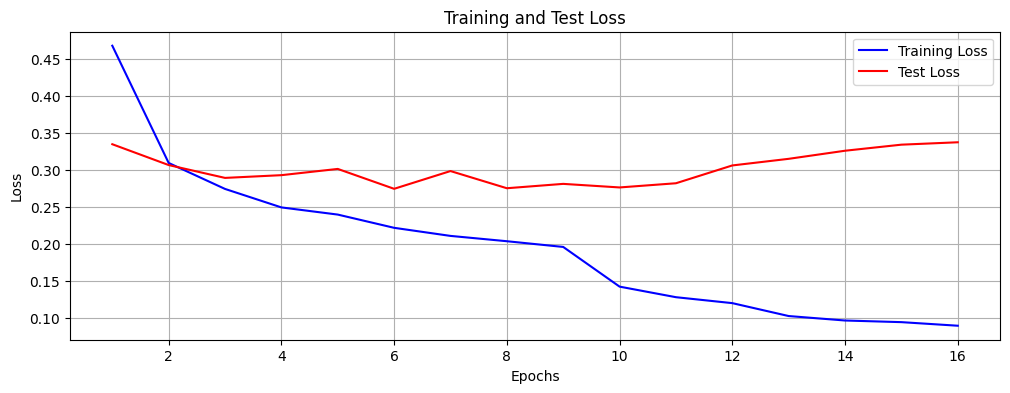

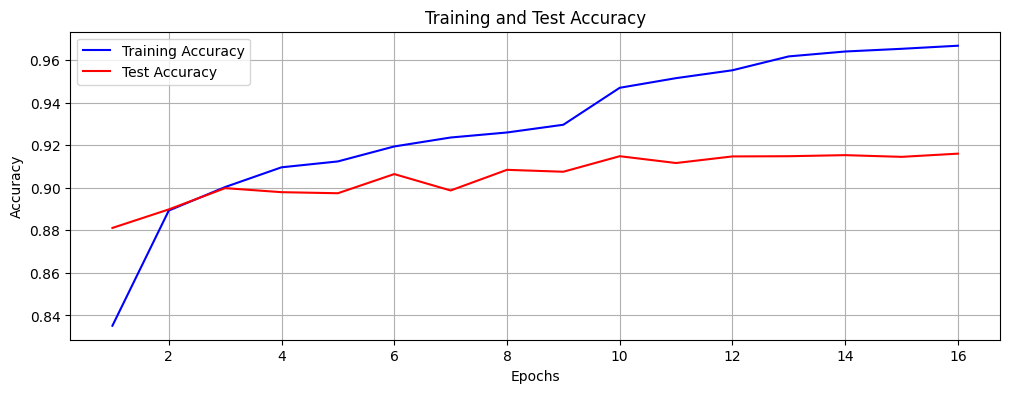

In [41]:
plt.figure(figsize=(12, 4))
loss_values=history.history['loss']
test_loss_values=history.history['val_loss']
epochs=range(1,len(history.history['loss'])+1)
plt.plot(epochs,loss_values,'b',label='Training Loss')
plt.plot(epochs,test_loss_values,'b',label='Test Loss',color='red')
plt.title('Training and Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.legend()



plt.figure(figsize=(12, 4))
loss_values=history.history['accuracy']
test_loss_values=history.history['val_accuracy']
epochs=range(1,len(history.history['accuracy'])+1)
plt.plot(epochs,loss_values,'b',label='Training Accuracy')
plt.plot(epochs,test_loss_values,'b',label='Test Accuracy',color='red')
plt.title('Training and Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

In [42]:
results = model.evaluate(x_test_resized, y_test)
print(results)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9028 - loss: 0.2755
[0.27440378069877625, 0.9064000248908997]


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


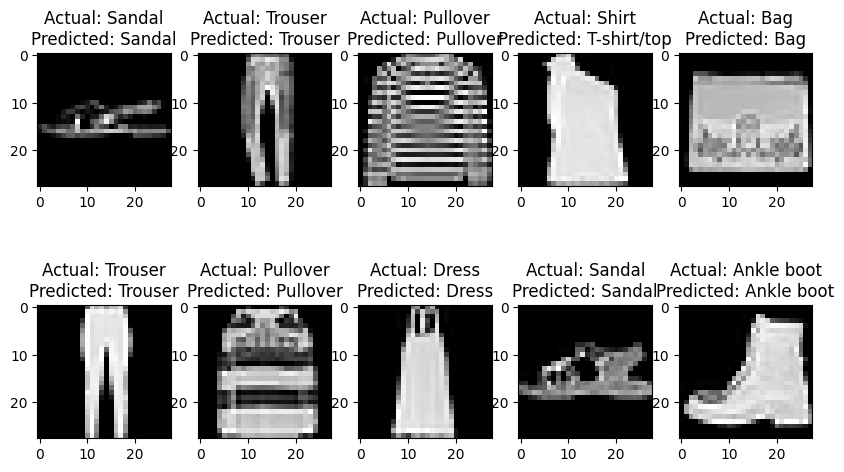

In [46]:
y_predict = model.predict(x_test_resized)

random_index = np.random.choice(x_test.shape[0],10,replace=False)

plt.figure(figsize=(10, 6))

for i,index in enumerate(random_index):
  plt.subplot(2,5,i+1)
  plt.imshow(x_test[index])
  plt.title(f'Actual: {class_names[y_test[index]]}\nPredicted: {class_names[np.argmax(y_predict[index])]}')

plt.show()

Задаопомогою донавчання та виділення ознак вдалося досягти досить великої точності 0,9064. І на тестах показав кращий результат ніж багатошарова мережа але гірше ніж згорткова мережа. На мою думку це повязано з тим що картинки потрібно було з 1 канальних зображень перевести в 3 канальні бо архітектура VGG16 з вагами "imagenet" очікує зображення в форматі RGB. Тому я вважаю що якщо б картинки були б одразу в RGB то результат був кращим і для таких зображень доцільно використовувати згорткову мережу яка натренована цих зображеннях щоб отримати найкращий результат.